#Markdown by Karol Rejek

# Agentowy asystent RAG

Przeżyłeś katastrofę Titanica i lądujesz na bezludnej wyspie. Masz przy sobie tylko teczkę z **plikami PDF** i terminal. Agent z zewnątrz zrzuca na ciebie odpowiedzialność za operację – musisz to ogarnąć. Zbuduj **asystenta**, który przejmie zadania techniczne i zagwarantuje ci wyłącznie sprawdzone odpowiedzi. Mechanizm jest prosty: system ma korzystać stricte z ocalałych dokumentów, całkowicie odciąć **halucynacje** i od razu zgłaszać brak wiedzy, jeśli danej informacji nie ma w plikach.

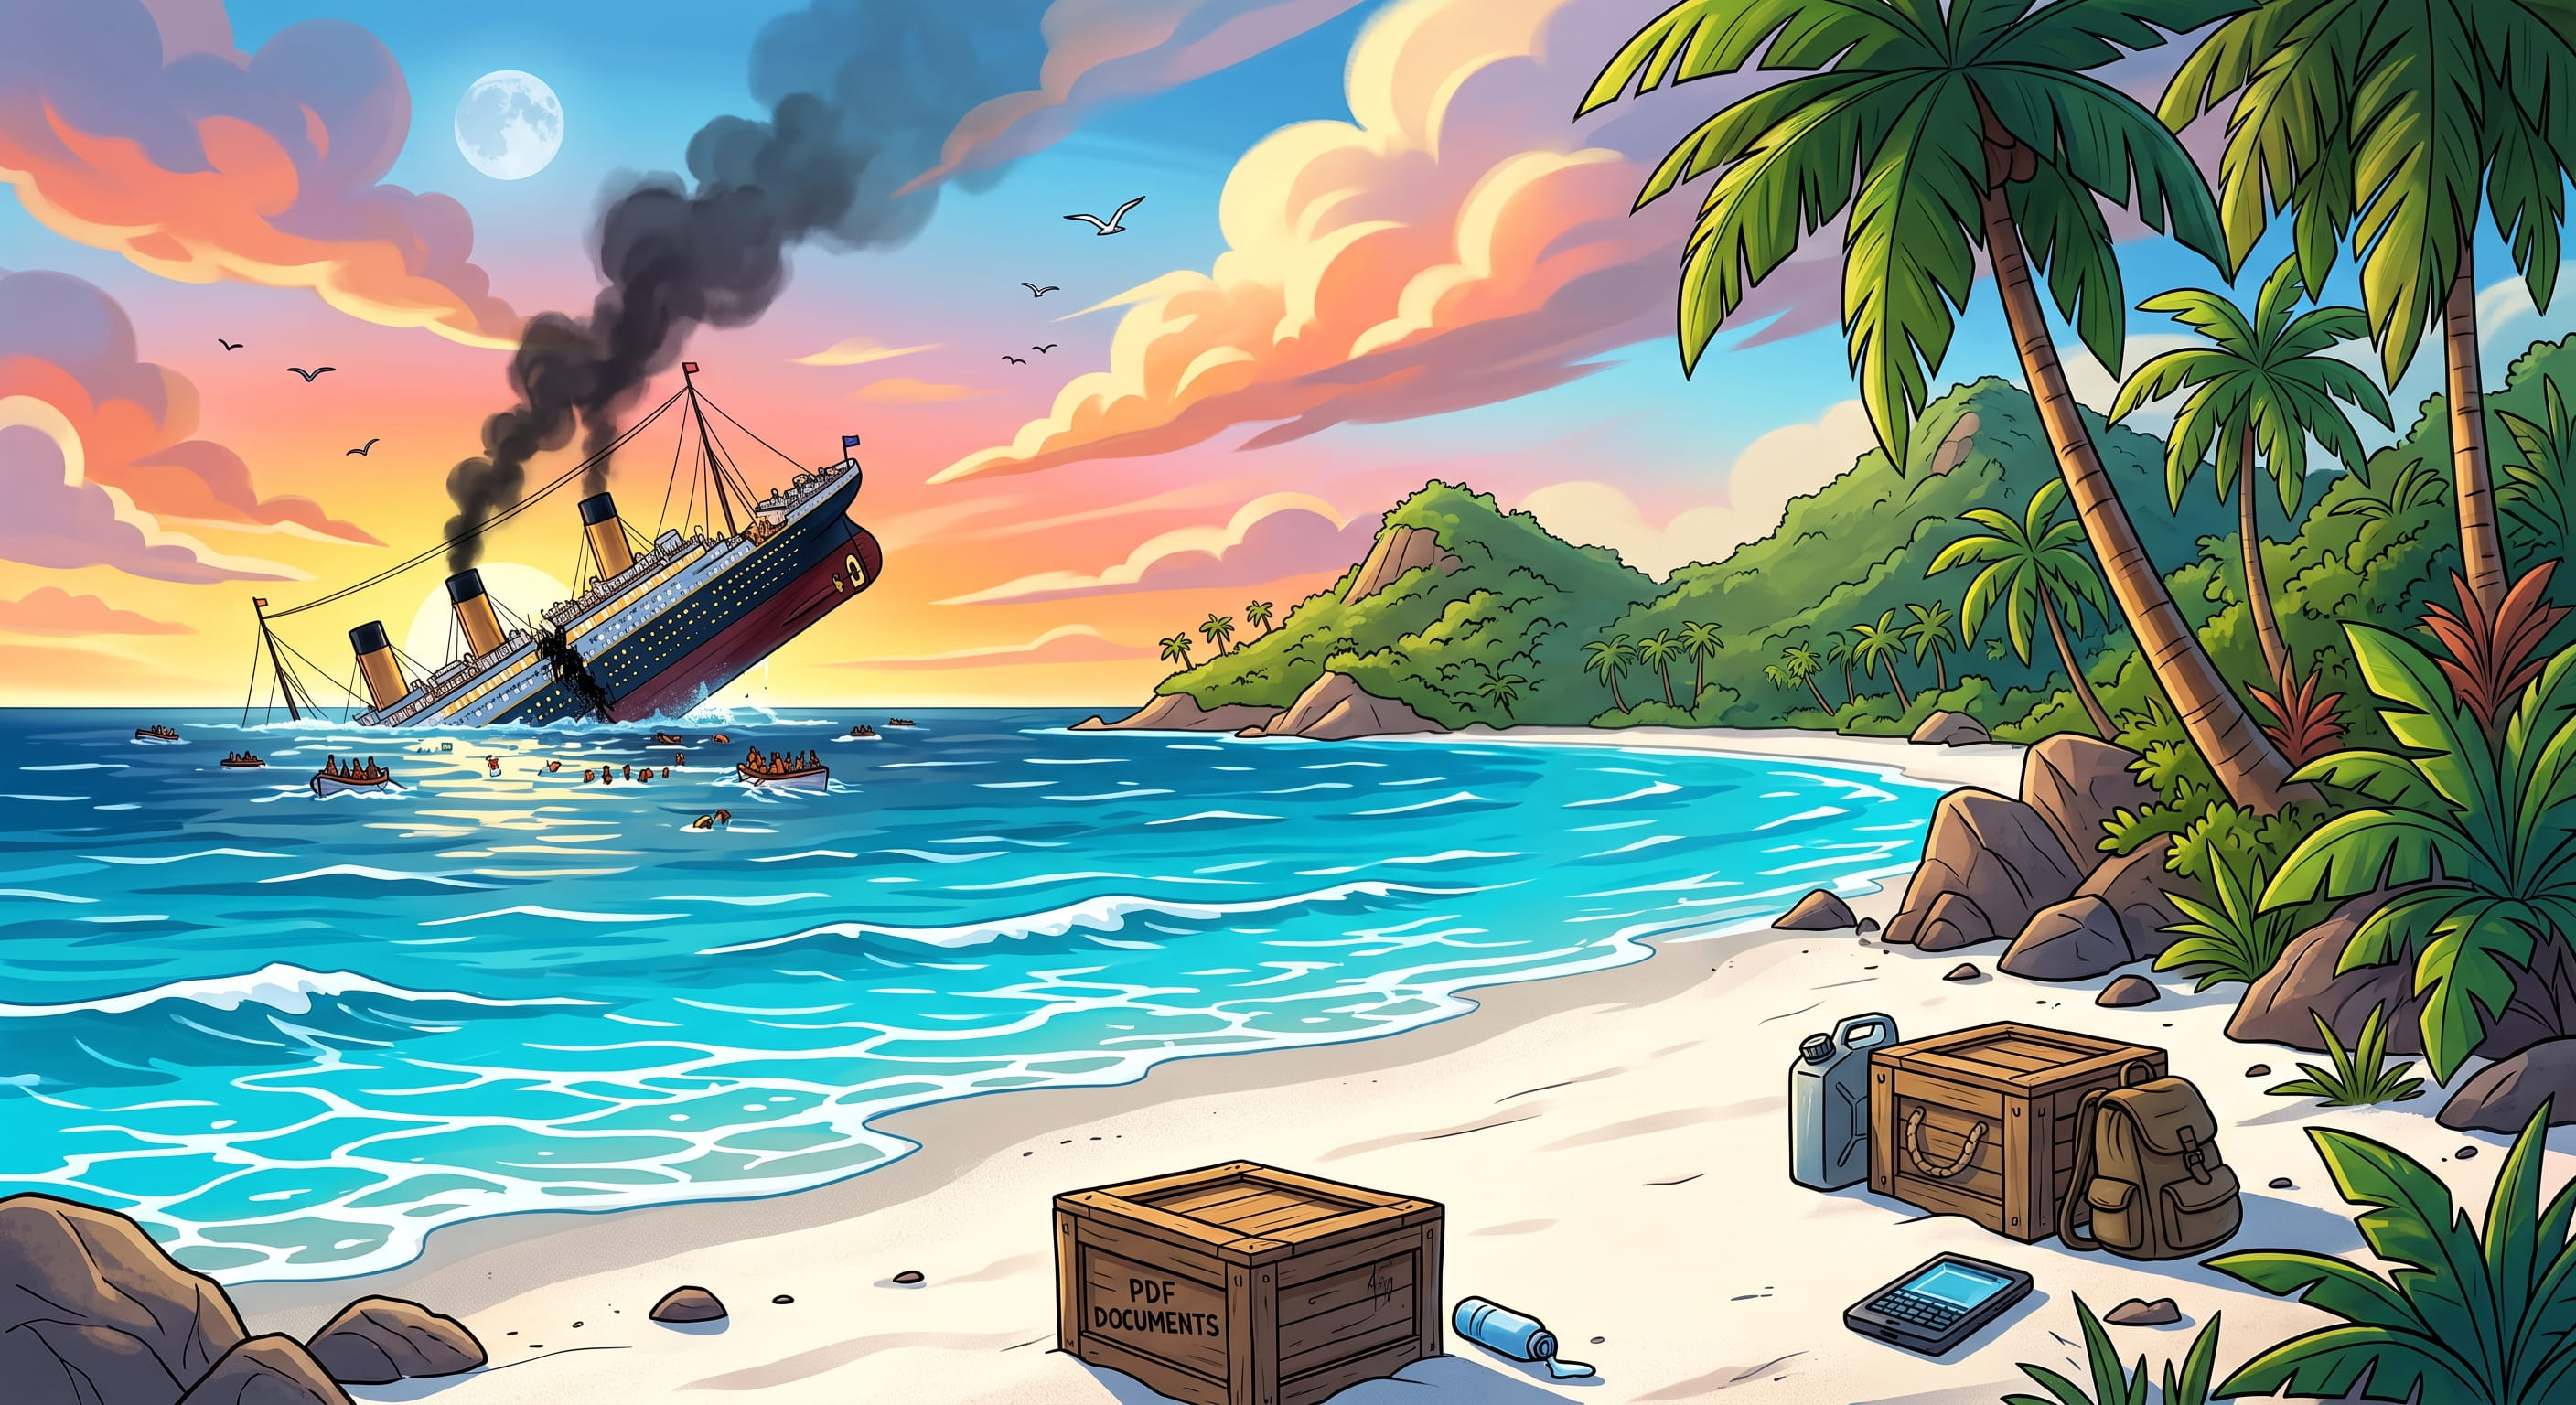

(generated with AI)

### A. Co budujesz

Asystenta **agentowego**, nie klasycznego RAG-a. Klasyczny RAG to sztywno ustalony przebieg postępowania:

(`embed → pobierz → wklej kontekst → generuj`)

 — zawsze te same kroki, żadnej decyzji.

**Agent** sam decyduje,
czy, kiedy i którego narzędzia użyć, ogląda wynik i może wykonać kolejny krok.

### B. Proponowana zawężona tematyka PDF

Zbierz **3–5 PDF-ów na jeden, spójny temat** i wrzuć do folderu.

**Przepisy kulinarne** — trzeba nakarmić innych rozbitków. Przykładowe drugie narzędzie:
przeliczanie porcji, lista zakupów z kilku przepisów, porównanie z zawartością spiżarni, sumowanie czasu przygotowania.

**Instrukcje obsługi** (jakieś przedmioty przydatne do przetrwania). Przykładowe drugie narzędzie:
zużycie paliwa, przelicznik jednostek (PSI ↔ bar, °F ↔ °C), harmonogram serwisu, wyszukiwarka kodów błędów.

Drugie narzędzie ma mieć **weryfikowalne wyjście** — takie, po którym widać, że policzyło, a nie zgadło.
Narzędzie, które tylko przepisuje tekst albo którego agent nigdy nie wywoła, się nie liczy.

### C. Wybór narzędzi

| Warstwa | Czego najlepiej użyć |
|---|---
| Parsowanie PDF | PyMuPDF
| Podział na fragmenty | `RecursiveCharacterTextSplitter` |
| Embeddingi | model z HuggingFace |
| Baza wektorowa | Chroma lub Qdrant |
| Model generatywny | darmowe API z **natywnym tool callingiem** (Groq, Gemini) |
| Agent | `create_agent` z LangChain |
| Pamięć | `InMemorySaver` z LangGraph |

### D. Polecenie:

- Załaduj 5 dokumentów PDF dotyczących wybranej tematyki, podział na strony, umieść je w folderze na dysku
- Pamiętaj o kluczu do LLM, trzymaj go w folderze `.env`
- Podziel strony na chunki
- Wybierz model do embeddingów z HuggingFace
- Utwórz bazę wektorową i wypełnij ją danymi
- Zdefiniuj **co najmniej** 2 narzędzia
- Zbuduj agenta, który opiera się na ustalonym prompcie systemowym
- Sprawdź jak działa, zadając pytania (nie)dotyczące dokumentów z bazy

**Dodatkowe wymagania:**
- Mechanizm pamięci konwersacji - tak, żeby model pamiętał poprzednią część konwersacji
- Mechanizm braku halucynacji - jeśli model nie znajdzie odpowiedzi w bazie, informuje o tym
- Cytowanie dokumentu, z którego model pobrał informacje

**Dla chętnych:**
- Model-sędzia (LLM-as-judge) - ocena generowanych odpowiedzi (faithfulness, answer relevancy)
- Retrieval metrics: hit rate@k, MRR
- Rewriting pytań zależnych od kontekstu (zaimki) przed retrievalem
- Lepsze czyszczenie PDF (OCR, czyszczenie), tuning chunk_size/chunk_overlap

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza Markdown.

### 1. Środowisko i dane

In [1]:
from dotenv import load_dotenv
load_dotenv()

False

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from dotenv import load_dotenv
import os

env_path = "/content/drive/MyDrive/AgentSurvival/.env"
load_dotenv(dotenv_path=env_path)

gemini_api_key = os.environ.get("GEMINI_API_KEY")
assert gemini_api_key is not None, "Brak klucza GEMINI_API_KEY w pliku .env!"

In [9]:
!pip install -U langchain langchain-community langchain-text-splitters langchain-huggingface sentence-transformers chromadb langchain-chroma pymupdf
!pip install langchain-google-genai
!pip install python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.0/148.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/

In [10]:
import os
import glob
from langchain_community.document_loaders import PyMuPDFLoader

pdf_folder = "/content/drive/MyDrive/AgentSurvival/PdfFiles"
pdf_paths = glob.glob(os.path.join(pdf_folder, "*.pdf"))

print(f"Znaleziono {len(pdf_paths)} plików PDF:")
for path in pdf_paths:
    print(f" - {os.path.basename(path)}")

/tmp/ipykernel_1385/1928372604.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


Znaleziono 5 plików PDF:
 - 7128-gp3500io-portable-generator-owners-manual.pdf
 - d0234f89-863b-42b5-8081-1b28124a69cd.pdf
 - 6dbe8443f210aa855cafa8a01ac6731158135a30a9130b0acceb80a0af67d252_optim.pdf
 - 4aed0d.pdf
 - 71+shgZNMuL.pdf


In [28]:
def load_all_pdfs(pdf_paths: list[str]) -> list:
    all_pages = []
    for path in pdf_paths:
        loader = PyMuPDFLoader(path)
        pages = loader.load()
        all_pages.extend(pages)
    return all_pages

all_pages = load_all_pdfs(pdf_paths)
print(f"Łączna liczba wczytanych stron: {len(all_pages)}")

Łączna liczba wczytanych stron: 170


### Wczytywanie dokumentów źródłowych

Jako bazę wybrałem instrukcje obsługi urządzeń zasilających przydatnych w scenariuszu survivalowym, czyli dwa generatory prądu, dwa panele słoneczne oraz jeden powerbank, co daje 5 dokumentów w ramach jednej spójnej kategorii
"zasilanie awaryjne".

Ze wszystkich plików uzyskałem łącznie 170 stron, co moim zdaniem stanowi solidną podstawę do dalszego przetwarzania.

In [33]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 300,
    chunk_overlap = 50,
    length_function = len,
    separators = ["\n\n", "\n", ".", " ", ""],
)

In [34]:
docs = text_splitter.split_documents(all_pages)
print(f"Łączna liczba podzielonych fragmentów: {len(docs)}")

Łączna liczba podzielonych fragmentów: 1260


### Dobór parametrów chunkingu

Przetestowałem dwie konfiguracje `RecursiveCharacterTextSplitter`:
- `chunk_size=500, chunk_overlap=100` → 787 fragmentów,
- `chunk_size=300, chunk_overlap=50` → 1260 fragmentów.

Mniejsze fragmenty okazały się korzystniejsze dla tekstu opisowego instrukcji, ponieważ zmniejszały ryzyko wymieszania niepowiązanych sekcji w jednym chunku, choć kosztem nieznacznego powielania treści na granicach chunków wynikającego z zastosowanego overlapu. Ostatecznie przyjąłem `chunk_size=300, chunk_overlap=50` jako lepszy kompromis między spójnością semantyczną, a liczbą fragmentów.

In [35]:
for idx, doc in enumerate(docs[75:79]):
    print(f"{idx}. {doc.page_content}\n---")

0. and to gradually reduce the use of the
choke.
•
The CHOKE position (3) switches the fuel
valve on to start the engine.
NOTE: The CHOKE is not required to start a
warm engine.
Figure 2-5. Switch (example)
USB Outlets
The 5 VDC, 1/2.1 Amp USB outlet allows
charging of compatible electronic devices.
---
1. charging of compatible electronic devices.
Economy Switch
The economy switch has 2 modes of opera-
tion:
•
On: The quietest mode and best when run-
ning appliances or equipment that are
resistive loads (non-motor starting), (exam-
ple: TV, video game, light, radio).
•
---
2. ple: TV, video game, light, radio).
•
Off: Best when running a both inductive
(motor-starting loads) and resistive (non-
motor starting loads), especially when
these loads are turning on and off (exam-
ple: RV, air conditioner, hairdryer).
Generator Status Lights
See Figure 2-6.
•
---
3. Generator Status Lights
See Figure 2-6.
•
Overload LED (red): Indicates system
overload (2). During motor starting it is nor-
m

### Wybór modelu embeddingów

Do embeddingów zdecydowałem się na model `sentence-transformers/all-MiniLM-L6-v2` z HuggingFace. Jest to lekki model generujący wektory 384-wymiarowe, wystarczająco szybki do pracy na CPU w Google Colab, a przy tym sprawdzony w zadaniach wyszukiwania semantycznego. Przy ~1260 fragmentach obliczenie wszystkich embeddingów zajęło rząd kilkudziesięciu sekund, co uznałem za w pełni akceptowalne dla iteracyjnej pracy w notebooku, bez konieczności sięgania po cięższe modele wymagające GPU.

In [36]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [37]:
from langchain_chroma import Chroma

chroma_path = "/content/drive/MyDrive/AgentSurvival/chroma_db"

vectorstore = Chroma.from_documents(
    documents = docs,
    embedding = embeddings,
    persist_directory = chroma_path,
)

In [38]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

results = retriever.invoke("What is the fuel consumption of the generator?")
for doc in results:
    print(doc.page_content)
    print(f"Źródło: {doc.metadata.get('source')}, strona: {doc.metadata.get('page')}")
    print("---")

container. 
 
IMPORTANT: 
For continuous operation, be prepared to check and refuel the generator on 
a regular basis. A tank of gasoline should last about 8.5 hours @ 1/4 load. 
 
Inspect Fuel 
System / Check 
for Leaks 
Inspect fuel system & check for leaks BEFORE starting generator.
Źródło: /content/drive/MyDrive/AgentSurvival/PdfFiles/4aed0d.pdf, strona: 28
---
750 W 
  Refrigerator Freezer 
1500 W 
  Microwave Oven 1000W 
1000 W 
  Air Conditioner, Window (10,000 BTU) 
2200 W 
  Sump pump (1/3 hp) 
1300 W 
Total  
6750W 
 
In this example, the generator must have a continuous output of at least 6750 watts in order to
Źródło: /content/drive/MyDrive/AgentSurvival/PdfFiles/4aed0d.pdf, strona: 14
---
wattage. 
 
3. Add the wattages for all devices on your list.  This total must be lower than the continuous 
output rating of your generator.   
 
Example: 
 
Device to be Powered 
Greater of 
Starting/Running Wattage 
  Light Bulbs (10 – 75 watt) 
750 W 
  Refrigerator Freezer 
1500 W
Źr

In [39]:
from langchain_core.tools import tool
import os

def format_doc_with_citation(doc) -> str:
    """Formatuje pojedynczy fragment dokumentu wraz z cytowaniem źródła."""
    file_name = os.path.basename(doc.metadata.get("source", "nieznany plik"))
    page_number = doc.metadata.get("page", "?")
    return f"{doc.page_content}\n[Źródło: {file_name}, strona {page_number}]"

@tool
def search_knowledge_base(query: str) -> str:
    """Searches the knowledge base for information from the loaded PDF manuals.
    Use this tool when the user asks about the content of the survival equipment manuals."""

    docs = retriever.invoke(query)

    if not docs:
        return "Brak informacji na ten temat w bazie wiedzy."

    formatted_results = [format_doc_with_citation(doc) for doc in docs]
    return "\n---\n".join(formatted_results)

result = search_knowledge_base.invoke("What is the fuel consumption of the generator?")
print(result)

container. 
 
IMPORTANT: 
For continuous operation, be prepared to check and refuel the generator on 
a regular basis. A tank of gasoline should last about 8.5 hours @ 1/4 load. 
 
Inspect Fuel 
System / Check 
for Leaks 
Inspect fuel system & check for leaks BEFORE starting generator.
[Źródło: 4aed0d.pdf, strona 28]
---
750 W 
  Refrigerator Freezer 
1500 W 
  Microwave Oven 1000W 
1000 W 
  Air Conditioner, Window (10,000 BTU) 
2200 W 
  Sump pump (1/3 hp) 
1300 W 
Total  
6750W 
 
In this example, the generator must have a continuous output of at least 6750 watts in order to
[Źródło: 4aed0d.pdf, strona 14]
---
wattage. 
 
3. Add the wattages for all devices on your list.  This total must be lower than the continuous 
output rating of your generator.   
 
Example: 
 
Device to be Powered 
Greater of 
Starting/Running Wattage 
  Light Bulbs (10 – 75 watt) 
750 W 
  Refrigerator Freezer 
1500 W
[Źródło: 4aed0d.pdf, strona 14]


In [40]:
from pydantic import BaseModel, Field
from typing import List


class Device(BaseModel):
    """Pojedyncze urządzenie elektryczne wraz z jego poborem mocy."""
    name: str = Field(description="Nazwa urządzenia, np. 'lodówka', 'mikrofalówka'")
    watts: float = Field(description="Pobór mocy urządzenia w watach (W)")

In [41]:
@tool
def calculate_power_balance(devices: List[Device], power_source_watts: float) -> str:
    """Calculates whether a given power source (generator, solar panel, power bank)
    can supply enough power for a list of devices.
    Use this tool whenever the user asks if a power source can run certain devices,
    or wants to know the total power demand of a list of appliances.
    If you know the wattage of a device from the knowledge base, use that value here
    instead of asking the user."""

    total_watts = sum(device.watts for device in devices)
    margin = power_source_watts - total_watts

    device_list_text = "\n".join(
        f"- {device.name}: {device.watts} W" for device in devices
    )

    if margin >= 0:
        verdict = f"WYSTARCZY — nadwyżka mocy: {margin:.0f} W"
    else:
        verdict = f"NIE WYSTARCZY — brakuje: {abs(margin):.0f} W"

    return (
        f"Lista urządzeń:\n{device_list_text}\n\n"
        f"Całkowite zapotrzebowanie: {total_watts:.0f} W\n"
        f"Dostępna moc źródła zasilania: {power_source_watts:.0f} W\n"
        f"Wniosek: {verdict}"
    )

In [43]:
test_devices = [
    Device(name="żarówki", watts=750),
    Device(name="lodówka", watts=1500),
    Device(name="mikrofalówka", watts=1000),
    Device(name="klimatyzacja", watts=2200),
    Device(name="pompa", watts=1300),
]

result = calculate_power_balance.invoke({
    "devices": test_devices,
    "power_source_watts": 6000,
})
print(result)

Lista urządzeń:
- żarówki: 750.0 W
- lodówka: 1500.0 W
- mikrofalówka: 1000.0 W
- klimatyzacja: 2200.0 W
- pompa: 1300.0 W

Całkowite zapotrzebowanie: 6750 W
Dostępna moc źródła zasilania: 6000 W
Wniosek: NIE WYSTARCZY — brakuje: 750 W


In [51]:
@tool
def calculate_battery_runtime(device_watts: float, battery_capacity_wh: float) -> str:
    """Calculates how many hours a device can run on a battery or power bank
    with a given energy capacity (in watt-hours).
    Use this tool when the user asks how long a device can run on a battery/power bank,
    given the device's power draw and the battery's capacity."""

    runtime_hours = battery_capacity_wh / device_watts

    return (
        f"Pobór mocy urządzenia: {device_watts:.1f} W\n"
        f"Pojemność baterii/powerbanku: {battery_capacity_wh:.1f} Wh\n"
        f"Szacowany czas pracy: {runtime_hours:.1f} h"
    )

In [52]:
result = calculate_battery_runtime.invoke({
    "device_watts": 10,
    "battery_capacity_wh": 50,
})
print(result)

Pobór mocy urządzenia: 10.0 W
Pojemność baterii/powerbanku: 50.0 Wh
Szacowany czas pracy: 5.0 h


In [54]:
from typing import Literal

@tool
def convert_units(
    value: float,
    conversion: Literal["btu_to_w", "w_to_btu", "wh_to_mah", "mah_to_wh"],
    voltage: float = 5.0,
) -> str:
    """Converts between units commonly found in power equipment manuals:
    BTU/h <-> Watts (for air conditioners), and Wh <-> mAh (for power banks, requires voltage).
    Use this tool whenever the user needs to convert a value between these units.
    The voltage parameter defaults to 5.0V (typical USB power bank output) and is only
    used for wh_to_mah and mah_to_wh conversions."""

    if conversion == "btu_to_w":
        result = value * 0.29307107
        return f"{value} BTU/h -> {result:.2f} W"
    elif conversion == "w_to_btu":
        result = value / 0.29307107
        return f"{value} W -> {result:.2f} BTU/h"
    elif conversion == "wh_to_mah":
        result = (value * 1000) / voltage
        return f"{value} Wh -> {result:.2f} mAh"
    elif conversion == "mah_to_wh":
        result = (value * voltage) / 1000
        return f"{value} mAh -> {result:.2f} Wh"
    else:
        raise ValueError(f"Nieznany typ konwersji: {conversion}")

In [57]:
result = convert_units.invoke({"value": 10000,"conversion": "btu_to_w"})
print(result)

result_back = convert_units.invoke({"value": 2930.71, "conversion": "w_to_btu"})
print(result_back)

result_energy = convert_units.invoke({"value": 20000, "conversion": "mah_to_wh", "voltage": 5.0})
print(result_energy)

10000.0 BTU/h -> 2930.71 W
2930.71 W -> 10000.00 BTU/h
20000.0 mAh -> 100.00 Wh


### Budowa agenta

Agenta zbudowałem przez `create_agent`, wykorzystując model `google_genai:gemini-3.1-flash-lite`. Do agenta podpiąłem oba zdefiniowane wcześniej narzędzia oraz `InMemorySaver` jako mechanizm pamięci konwersacji.

W system prompcie zawarłem pięć zasad postępowania:
1. priorytet przeszukiwania bazy wiedzy przed udzieleniem odpowiedzi
2. preferowanie danych z dokumentów nad pytaniem użytkownika przy obliczeniach mocy
3. obowiązek jawnego zgłaszania braku danych,
4. konieczność cytowania źródeł
5. jasne rozgraniczenie wiedzy własnej modelu od wiedzy pochodzącej z dokumentacji

In [44]:
SYSTEM_PROMPT = """Jesteś asystentem rozbitka, który pomaga zarządzać sprzętem survivalowym na bezludnej wyspie.
Masz dostęp do instrukcji obsługi urządzeń zasilających (generatory, panele słoneczne, powerbanki) oraz kalkulatora bilansu mocy.

Zasady:
1. Zawsze, gdy pytanie dotyczy konkretnego urządzenia z instrukcji (np. jego mocy, zużycia paliwa, sposobu obsługi),
   najpierw użyj narzędzia search_knowledge_base, zanim odpowiesz.
2. Jeśli chcesz obliczyć bilans mocy, a znasz wartości watów urządzeń z bazy wiedzy, użyj ich w calculate_power_balance
   zamiast pytać użytkownika o dane, które już znasz z dokumentów.
3. Jeśli narzędzie search_knowledge_base zwróci informację o braku danych, jasno przekaż to użytkownikowi -
   nigdy nie zgaduj ani nie wymyślaj informacji, których nie ma w bazie wiedzy.
4. Zawsze cytuj źródło (nazwę pliku i numer strony), gdy odpowiadasz na podstawie danych z bazy wiedzy.
5. Jeśli pytanie nie dotyczy dokumentów ani obliczeń mocy (np. pytanie ogólne, niezwiązane z survivalowym sprzętem),
   odpowiedz na podstawie własnej wiedzy, ale zaznacz, że nie pochodzi ona z dokumentów.
"""

In [58]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent

tools = [search_knowledge_base, calculate_power_balance, convert_units, calculate_battery_runtime]

agent = create_agent(
    model = "google_genai:gemini-3.1-flash-lite",
    tools = tools,
    system_prompt = SYSTEM_PROMPT,
    checkpointer = InMemorySaver(),
)

In [47]:
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(configurable={"thread_id": "test-1"})

def run_agent(query: str, config: RunnableConfig):
    result = agent.invoke(
        {"messages": [{"role": "user", "content": query}]},
        config,
    )
    return result["messages"][-1].content

In [59]:
result_list = list()

result_list.append(run_agent("Jakie jest zużycie paliwa generatora", config))
result_list.append(run_agent("Jaka jest stolica Francji", config))
result_list.append(run_agent("O co Cię pytałem wcześniej?", config))
result_list.append(run_agent("Ile godzin może pracować generator na pełnym baku przy obciążeniu 1/4?", config))
result_list.append(run_agent("Mam klimatyzację 10000 BTU, ile to watów?", config))
result_list.append(run_agent("Mam powerbank 20000 mAh przy 5V, jak długo pociągnie telefon pobierający 10W?", config))

for res in result_list:
    print(res)

[{'type': 'text', 'text': 'Niestety, w dostępnej instrukcji obsługi generatora (7128-gp3500io-portable-generator-owners-manual.pdf) nie znalazłem informacji dotyczących konkretnego zużycia paliwa. Dokument skupia się głównie na zasadach bezpieczeństwa, budowie urządzenia oraz wskazówkach dotyczących konserwacji.', 'extras': {'signature': 'EnEKbwERTTIPmYSQNvPO8ygkAmyutO0etdC3nCDPcR/MZUMsx/VShLP0zsUMvKxP9844xRPkGeP+QUGOYOzbGpuOt/S3ePmthfWEPTLa3PPPFjO+sTYmgj47eWBDDhQy5v+JCUZdSkpbQOI56W1V0PhioA=='}}]
[{'type': 'text', 'text': 'Stolicą Francji jest Paryż. \n\n*Uwaga: Ta informacja nie pochodzi z dokumentacji sprzętu survivalowego, lecz z mojej ogólnej wiedzy.*', 'extras': {'signature': 'EnEKbwERTTIPjbzhxXvh8KxdVxG6LfCuhEB5FD5G4Xf/lymFvaPVHMtTrDUTnIk8ytflBirXe80h/9RCXyc7XxySn6IjWFpPXp5fJYXS8u2bfz/cws71BytF1gMAhhIIP/s9q0z2xL/TVRqvAVfqfFr92g=='}}]
[{'type': 'text', 'text': 'Wcześniej pytałeś mnie o zużycie paliwa generatora.', 'extras': {'signature': 'EnEKbwERTTIPoGAMSgtqTqyYneFEAeVKBM7I41DLaT

## Testy końcowe i wnioski

Przeprowadziłem sześć testów agenta. Pytanie o zużycie paliwa generatora (GP3500iO) potwierdziło mechanizm braku halucynacji (Agent zgłosił brak danych zamiast zgadywać). Pytanie o stolicę Francji pokazało, że agent odpowiada spoza dokumentacji, jawnie to zaznaczając. Test pamięci (`InMemorySaver`) wypadł poprawnie (Agent trafnie przypomniał wcześniejsze pytanie o paliwo). Czas pracy generatora przy 1/4 obciążenia (8,5 h) został poprawnie zacytowany ze źródła (*4aed0d.pdf*,
str. 28). `convert_units` poprawnie przeliczył klimatyzację 10 000 BTU/h na 2930,71 W. Ostatni test pokazał, że agent potrafi łączyć narzędzia w jednym łańcuchu: przeliczył powerbank 20 000 mAh/5V na 100 Wh, a następnie policzył 10-godzinny czas pracy urządzenia 10 W.